# Wikipedia Data Science Article Network Analysis

**Research Question:** Which Wikipedia concepts are most central to understanding data science?

**Author:** Dany Drammeh  
**Date:** February 27th 2026  
**Data Source:** Wikipedia API

## Step 1: Import Libraries

In [1]:
pip install adjustText

In [2]:
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time
from collections import defaultdict
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 11

Libraries imported successfully.


## Step 2: Define Starting Articles

Start with core data science Wikipedia articles and explore their link networks.

In [3]:
seed_articles = [
    "Data_science",
    "Machine_learning",
    "Artificial_intelligence",
    "Deep_learning",
    "Big_data",
    "Statistics",
    "Statistical_inference",
    "Regression_analysis",
    "Probability",
    "Linear_regression",
    "Artificial_neural_network",
    "Random_forest",
    "Decision_tree",
    "Cluster_analysis",
    "K-means_clustering",
    "Support_vector_machine",
    "Python_(programming_language)",
    "R_(programming_language)",
    "Jupyter",
    "Pandas_(software)",
    "NumPy",
    "Data_mining",
    "Data_visualization",
    "Natural_language_processing",
    "Computer_vision"
]

Seed articles loaded: 25


In [1]:
def clean_title(title):
    return (
        title.replace("_", " ")
             .replace("(programming language)", "")
             .replace("(software)", "")
             .strip()
    )

## Step 3: Data Collection Functions

**Data Collection Method:**
- **Source:** Wikipedia API (https://en.wikipedia.org/w/api.php)
- **Library:** Python `requests` (no special libraries needed!)
- **Authentication:** None required (completely free!)
- **Data:** Hyperlinks between Wikipedia articles

In [2]:
def get_article_links(article_title, max_links=None, sleep_time=0.5):
    import requests
    import time

    base_url = "https://en.wikipedia.org/w/api.php"
    collected_links = []
    seen = set()
    cont = {}

    session = requests.Session()
    session.headers.update({
        "User-Agent": "WikipediaNetworkAnalysis/1.0 (student project; educational use)"
    })

    while True:
        params = {
            "action": "query",
            "format": "json",
            "titles": article_title,
            "prop": "links",
            "plnamespace": 0,
            "pllimit": "max"
        }
        params.update(cont)

        success = False
        for attempt in range(3):
            try:
                response = session.get(base_url, params=params, timeout=30)
                response.raise_for_status()
                data = response.json()
                success = True
                break
            except requests.exceptions.RequestException as e:
                print(f"Attempt {attempt + 1} failed for {article_title}: {e}")
                time.sleep(2)

        if not success:
            print(f"Could not retrieve URL data for {article_title}")
            return collected_links

        pages = data.get("query", {}).get("pages", {})

        for _, page_data in pages.items():
            if "missing" in page_data:
                print(f"Missing page: {article_title}")
                return collected_links

            for link in page_data.get("links", []):
                title = link["title"].replace(" ", "_")
                if title != article_title and title not in seen:
                    seen.add(title)
                    collected_links.append(title)

                    if max_links is not None and len(collected_links) >= max_links:
                        return collected_links

        if "continue" in data:
            cont = data["continue"]
            time.sleep(sleep_time)
        else:
            break

    return collected_links

In [3]:
test_links = get_article_links("Data_science", max_links=20)
print(f"Retrieved {len(test_links)} links from Data_science")

Retrieved 20 links from Data_science
['Academic_discipline', 'Algorithm', 'American_Statistical_Association', 'Analysis', 'Andrew_Gelman', 'ArXiv_(identifier)', 'Artificial_intelligence', 'Arvind_Narayanan', 'Astroinformatics', 'Astronomical_survey']


## Step 4: Collect Network Data

In [7]:
print("Collecting outgoing links from seed articles...\n")

seed_article_links = {}
all_seen_articles = set(seed_articles)

for i, article in enumerate(seed_articles, start=1):
    print(f"[{i:02d}/{len(seed_articles)}] {clean_title(article)}")
    links = get_article_links(article, max_links=500)
    seed_article_links[article] = links
    all_seen_articles.update(links)
    time.sleep(0.4)

print("\nFinished collecting seed article links.")
print(f"Seed articles processed: {len(seed_article_links)}")
print(f"Unique linked articles discovered: {len(all_seen_articles)}")


[01/25] Data science
[02/25] Machine learning
[03/25] Artificial intelligence
[04/25] Deep learning
[05/25] Big data
[06/25] Statistics
[07/25] Statistical inference
[08/25] Regression analysis
[09/25] Probability
[10/25] Linear regression
[11/25] Artificial neural network
[12/25] Random forest
[13/25] Decision tree
[14/25] Cluster analysis
[15/25] K-means clustering
[16/25] Support vector machine
[17/25] Python
[18/25] R
[19/25] Jupyter
[20/25] Pandas
[21/25] NumPy
[22/25] Data mining
[23/25] Data visualization
[24/25] Natural language processing
[25/25] Computer vision

Finished collecting seed article links.
Seed articles processed: 25
Unique linked articles discovered: 4703


## Step 5: Filter to Data Science Articles

In [8]:
article_mentions = defaultdict(int)

for source_article, links in seed_article_links.items():
    for target_article in links:
        article_mentions[target_article] += 1

mentions_df = (
    pd.DataFrame(article_mentions.items(), columns=["article", "mention_count"])
      .sort_values("mention_count", ascending=False)
      .reset_index(drop=True)
)

mentions_df["article_name"] = mentions_df["article"].apply(clean_title)

print("Top mentioned linked topics:")
print(mentions_df.head(20).to_string(index=False))

Top mentioned linked topics:
                            article  mention_count                        article_name
                   Doi_(identifier)             21                    Doi (identifier)
                  ISBN_(identifier)             21                   ISBN (identifier)
               Bibcode_(identifier)             19                Bibcode (identifier)
                  ISSN_(identifier)             19                   ISSN (identifier)
                 ArXiv_(identifier)             17                  ArXiv (identifier)
                   Machine_learning             16                    Machine learning
                  PMID_(identifier)             15                   PMID (identifier)
                   PMC_(identifier)             14                    PMC (identifier)
                   Cluster_analysis             13                    Cluster analysis
                        Data_mining             12                         Data mining
          Arti

In [36]:
def is_valid_concept_article(article):
    """
    Keep only core technical data science concepts.
    Filter out news, trends, timelines, and infrastructure.
    """
    article_lower = article.lower().replace("_", " ")

    # BLOCK these patterns first
    banned_patterns = [
        "isbn", "issn", "doi", "identifier", "arxiv (identifier)",
        "citation", "template:", "portal:", "category:",
        "wikipedia:", "wikidata", "commons",
        "timeline of", "history of", "list of", "outline of",
        "glossary of", "comparison of",
        "ai boom", "ai bubble", "ai winter", "ai alignment", "ai safety",
        "ai data center", "chatgpt", "gpt-", "generative ai",
        "llm", "large language model", "existential risk"
    ]

    for pattern in banned_patterns:
        if pattern in article_lower:
            return False

    # KEEP if it contains these technical terms
    technical_terms = [
        "algorithm", "learning", "network", "statistic", "probability",
        "regression", "classification", "clustering", "analysis",
        "data", "model", "prediction", "inference", "optimization",
        "matrix", "vector", "gradient", "neural", "deep",
        "supervised", "unsupervised", "reinforcement",
        "python", "programming", "software", "library",
        "visualization", "database", "mining", "processing",
        # ADD THESE for broader coverage
        "machine", "artificial", "intelligence", "science",
        "computer", "computing", "training", "testing"
    ]

    # Article must contain at least one technical term OR be a seed article
    has_technical_term = any(term in article_lower for term in technical_terms)

    return has_technical_term

In [37]:
MIN_MENTIONS = 5

core_articles = {
    article for article, count in article_mentions.items()
    if count >= MIN_MENTIONS and is_valid_concept_article(article)
}

# always keep seed articles, as long as they are conceptually valid
core_articles.update([article for article in seed_articles if is_valid_concept_article(article)])

core_articles = sorted(core_articles)

print(f"Minimum mentions threshold: {MIN_MENTIONS}")
print(f"Core article count after filtering: {len(core_articles)}")

Minimum mentions threshold: 5
Core article count after filtering: 175

Sample core articles:
['AAAI Conference on Artificial Intelligence', 'AI-assisted software development', 'Accelerated failure time model', 'Active learning (machine learning)', 'Actuarial science', 'Adversarial machine learning', 'Alex Graves (computer scientist)', 'Algorithm', 'Analysis of covariance', 'Analysis of variance', 'Applications of artificial intelligence', 'Apprenticeship learning', 'Artificial Intelligence Act', 'Artificial Intelligence Cold War', 'Artificial consciousness', 'Artificial general intelligence', 'Artificial human companion', 'Artificial intelligence', 'Artificial intelligence and elections', 'Artificial intelligence arms race', 'Artificial intelligence art', 'Artificial intelligence controversies', 'Artificial intelligence in architecture', 'Artificial intelligence in education', 'Artificial intelligence in fiction']


In [38]:
print("Collecting links for every core article...\n")

full_article_links = {}

for i, article in enumerate(core_articles, start=1):
    print(f"[{i:03d}/{len(core_articles)}] {clean_title(article)}")
    links = get_article_links(article, max_links=50)
    full_article_links[article] = links
    time.sleep(0.4)

print("\nFinished collecting links for all core articles.")


[001/175] AAAI Conference on Artificial Intelligence
[002/175] AI-assisted software development
[003/175] Accelerated failure time model
[004/175] Active learning (machine learning)
[005/175] Actuarial science
[006/175] Adversarial machine learning
[007/175] Alex Graves (computer scientist)
[008/175] Algorithm
[009/175] Analysis of covariance
[010/175] Analysis of variance
[011/175] Applications of artificial intelligence
[012/175] Apprenticeship learning
[013/175] Artificial Intelligence Act
[014/175] Artificial Intelligence Cold War
[015/175] Artificial consciousness
[016/175] Artificial general intelligence
[017/175] Artificial human companion
[018/175] Artificial intelligence
[019/175] Artificial intelligence and elections
[020/175] Artificial intelligence arms race
[021/175] Artificial intelligence art
[022/175] Artificial intelligence controversies
[023/175] Artificial intelligence in architecture
[024/175] Artificial intelligence in education
[025/175] Artificial intelligence i

## Step 6: Build Network Graph

In [39]:
G = nx.DiGraph()
G.add_nodes_from(core_articles)

for source_article, links in full_article_links.items():
    if not is_valid_concept_article(source_article):
        continue

    for target_article in links:
        if (
            target_article in core_articles
            and source_article != target_article
            and is_valid_concept_article(target_article)
        ):
            G.add_edge(source_article, target_article)

print("Network built successfully.")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")

Network built successfully.
Nodes: 175
Edges: 1969
Density: 0.0647


In [40]:
print("VALIDATION CHECKS")
print("-" * 50)

seed_in_graph = sum(1 for article in seed_articles if article in G.nodes())
isolates = list(nx.isolates(G))

print(f"Seed articles in graph: {seed_in_graph}/{len(seed_articles)}")
print(f"Isolated nodes: {len(isolates)}")
print(f"Self-loops: {nx.number_of_selfloops(G)}")

if G.number_of_nodes() > 0:
    print("Validation complete.")
else:
    print("Warning: graph is empty.")

VALIDATION CHECKS
--------------------------------------------------
Seed articles in graph: 21/25
Isolated nodes: 6
Self-loops: 0
Validation complete.


## Step 7: Define "Importance" and Calculate Centrality

In [41]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
in_degree_centrality = nx.in_degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G, alpha=0.85)
closeness_centrality = nx.closeness_centrality(G.to_undirected())

Calculating centrality metrics...
Centrality metrics calculated.


## Step 8: Create Analysis DataFrame

In [42]:
analysis_df = pd.DataFrame({
    "article": list(G.nodes()),
    "in_degree": [in_degree.get(n, 0) for n in G.nodes()],
    "out_degree": [out_degree.get(n, 0) for n in G.nodes()],
    "in_degree_centrality": [in_degree_centrality.get(n, 0) for n in G.nodes()],
    "betweenness": [betweenness_centrality.get(n, 0) for n in G.nodes()],
    "pagerank": [pagerank.get(n, 0) for n in G.nodes()],
    "closeness": [closeness_centrality.get(n, 0) for n in G.nodes()],
})

analysis_df["article_name"] = analysis_df["article"].apply(clean_title)

analysis_df = analysis_df.sort_values(
    by=["pagerank", "in_degree", "betweenness"],
    ascending=False
).reset_index(drop=True)

print("Top 15 most important nodes:")
print(
    analysis_df[
        ["article_name", "in_degree", "out_degree", "pagerank", "betweenness"]
    ].head(15).to_string(index=False)
)

Top 15 most important nodes:
                           article_name  in_degree  out_degree  pagerank  betweenness
           Adversarial machine learning         41          16  0.062043     0.094710
       AI-assisted software development         15          12  0.059223     0.027164
                Artificial intelligence         53           1  0.051289     0.017108
       Alex Graves (computer scientist)         39           3  0.049848     0.013281
Applications of artificial intelligence         41           3  0.026928     0.003824
                     Bayesian inference         48          10  0.019284     0.006625
             Bayesian linear regression         44          13  0.018881     0.008258
        Artificial general intelligence         32           5  0.017546     0.003745
       Artificial Intelligence Cold War         26           1  0.016836     0.000000
                              Algorithm         23           0  0.016617     0.000000
                   Bayesi

## Step 9: Identify Top 3 Most Important Concepts

In [49]:
top_3 = analysis_df.head(3)

print("Top 3 Most Important Concepts:")
for i, row in enumerate(top_3.itertuples(index=False), start=1):
    print(f"{i}. {row.article_name:30s} (in-degree: {row.in_degree}, PageRank: {row.pagerank:.4f})")

Top 3 Most Important Concepts:
1. Adversarial machine learning   (in-degree: 41, PageRank: 0.0620)
2. AI-assisted software development (in-degree: 15, PageRank: 0.0592)
3. Artificial intelligence        (in-degree: 53, PageRank: 0.0513)


Visualization 1 - Top Concepts by In-Degree

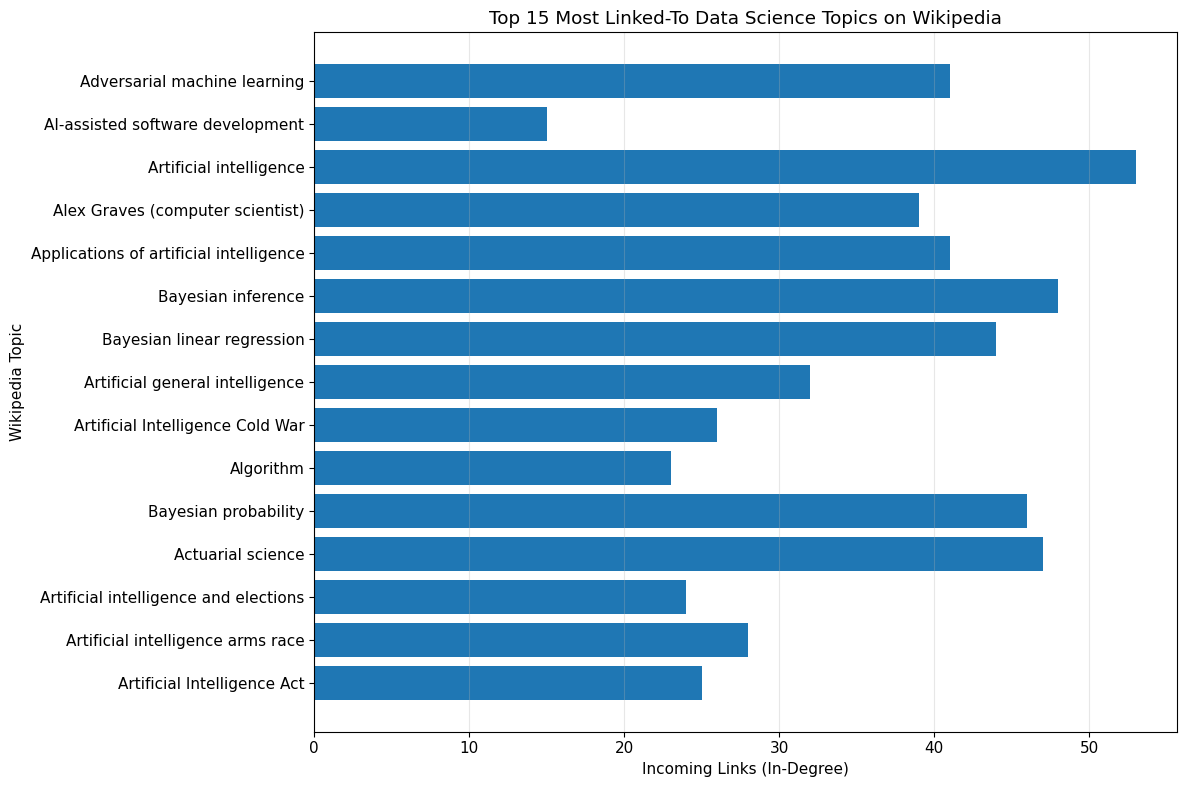

In [45]:
top_15 = analysis_df.head(15).copy()

plt.figure(figsize=(12, 8))
plt.barh(top_15["article_name"][::-1], top_15["in_degree"][::-1])
plt.xlabel("Incoming Links (In-Degree)")
plt.ylabel("Wikipedia Topic")
plt.title("Top 15 Most Linked-To Data Science Topics on Wikipedia")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Visualization 2 - Network Graph

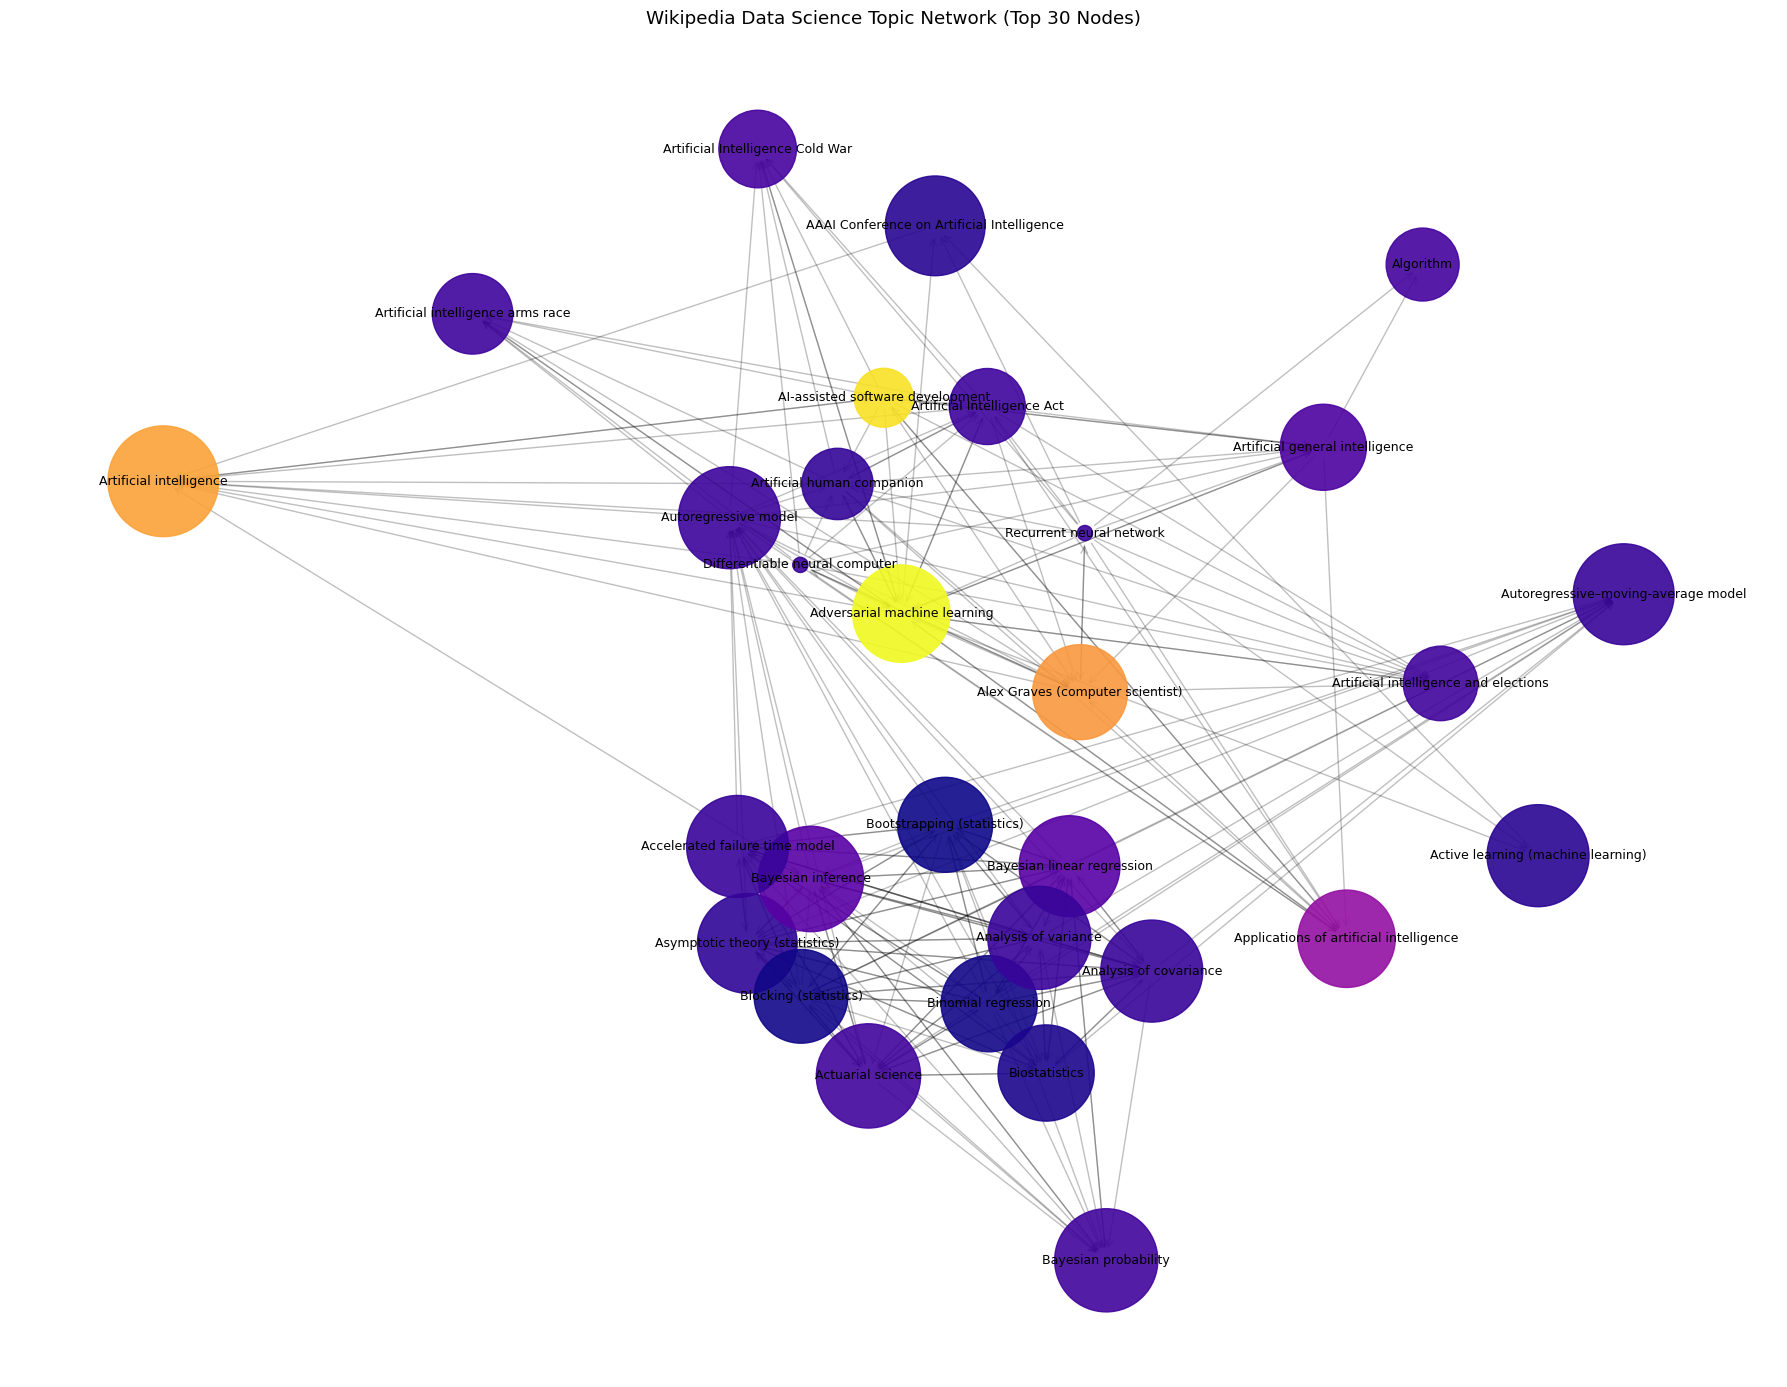

In [46]:
top_nodes = analysis_df.head(30)["article"].tolist()
subgraph = G.subgraph(top_nodes).copy()

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(subgraph, seed=42, k=1.1)

node_sizes = [max(in_degree.get(n, 1), 1) * 120 for n in subgraph.nodes()]
node_colors = [pagerank.get(n, 0) for n in subgraph.nodes()]
labels = {n: clean_title(n) for n in subgraph.nodes()}

nx.draw_networkx_nodes(
    subgraph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.9
)

nx.draw_networkx_edges(
    subgraph, pos,
    arrows=True,
    arrowstyle="->",
    arrowsize=12,
    alpha=0.25,
    width=1
)

nx.draw_networkx_labels(
    subgraph, pos,
    labels=labels,
    font_size=9
)

plt.title("Wikipedia Data Science Topic Network (Top 30 Nodes)")
plt.axis("off")
plt.tight_layout()
plt.show()

Visualization 3 - PageRank vs Betweenness

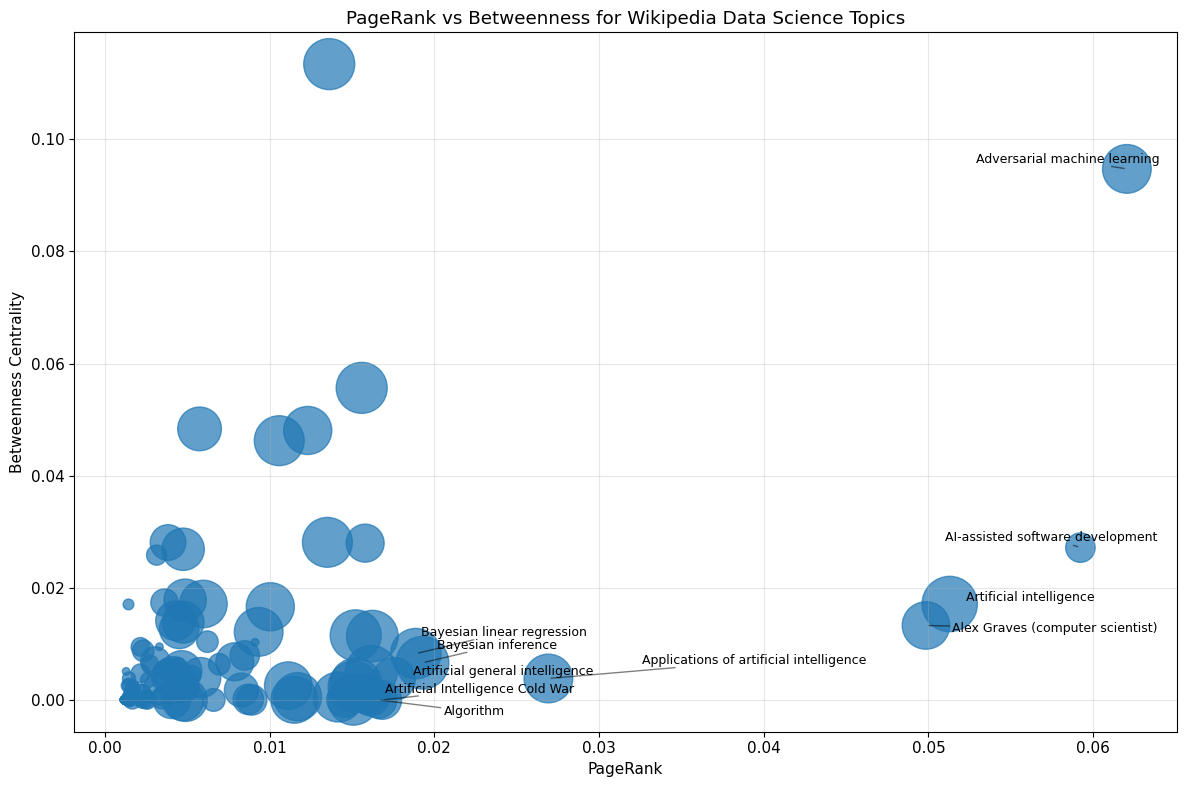

In [47]:
from adjustText import adjust_text

top_10 = analysis_df.head(10)

plt.figure(figsize=(12, 8))

plt.scatter(
    analysis_df["pagerank"],
    analysis_df["betweenness"],
    s=np.maximum(analysis_df["in_degree"], 1) * 30,
    alpha=0.7
)

texts = []

for row in top_10.itertuples(index=False):
    texts.append(
        plt.text(
            row.pagerank,
            row.betweenness,
            row.article_name,
            fontsize=9
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", alpha=0.5)
)

plt.xlabel("PageRank")
plt.ylabel("Betweenness Centrality")
plt.title("PageRank vs Betweenness for Wikipedia Data Science Topics")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Answer to Research Question

In [50]:
top_5 = analysis_df.head(5)

print("Top 5 central data science concepts:")
print(top_5[["article_name", "in_degree", "pagerank", "betweenness"]].to_string(index=False))

Top 5 central data science concepts:
                           article_name  in_degree  pagerank  betweenness
           Adversarial machine learning         41  0.062043     0.094710
       AI-assisted software development         15  0.059223     0.027164
                Artificial intelligence         53  0.051289     0.017108
       Alex Graves (computer scientist)         39  0.049848     0.013281
Applications of artificial intelligence         41  0.026928     0.003824
